# Price Elasticity Model Development
## Fitness Class Booking Analysis

In [1]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# =========================================================
# LOAD CLEANED DATASET
# =========================================================

df = pd.read_csv('/content/cleaned_preprocessed_dataset_Tejaswini Yeluduti.csv')

print("Dataset Loaded Successfully")

display(df.head())

Dataset Loaded Successfully


,activity_site_id,activity_description,booking_end_datetime,booking_start_time,max_bookees,number_booked,price_inr,year,month,day,day_name
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,14:45:00,-0.475775,12,-1.709436,2018,4,8,Sunday
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,14:45:00,-0.475775,15,-1.709436,2018,4,15,Sunday
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,14:45:00,-0.475775,14,-1.709436,2018,4,22,Sunday
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,14:45:00,-0.475775,9,-1.709436,2018,4,29,Sunday
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,14:45:00,-0.475775,7,-1.709436,2018,5,6,Sunday


In [3]:
df['booking_end_datetime'] = pd.to_datetime(
    df['booking_end_datetime']
)

df['year'] = df['booking_end_datetime'].dt.year
df['month'] = df['booking_end_datetime'].dt.month
df['day'] = df['booking_end_datetime'].dt.day
df['day_name'] = df['booking_end_datetime'].dt.day_name()

In [4]:
# =========================================================
# DATA PREPARATION
# =========================================================

df['price_inr'] = pd.to_numeric(
    df['price_inr'],
    errors='coerce'
)

df['number_booked'] = pd.to_numeric(
    df['number_booked'],
    errors='coerce'
)

df.dropna(inplace=True)

print("Data Preparation Completed")

Data Preparation Completed


In [5]:
# =========================================================
# FEATURE SELECTION
# =========================================================

X = df[['price_inr']]

y = df['number_booked']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (3289, 1)
Target Shape: (3289,)


In [6]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (2631, 1)
Testing Data Shape: (658, 1)


In [7]:
df['price_inr'] = pd.to_numeric(
    df['price_inr'],
    errors='coerce'
)

df['number_booked'] = pd.to_numeric(
    df['number_booked'],
    errors='coerce'
)

df.dropna(inplace=True)

In [8]:
# =========================================================
# BUILD LINEAR REGRESSION MODEL
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [9]:
# =========================================================
# MODEL PREDICTIONS
# =========================================================

y_pred = model.predict(X_test)

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [10]:
# =========================================================
# MODEL EVALUATION
# =========================================================

r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

print("R-Squared:", round(r2, 4))
print("Mean Squared Error:", round(mse, 4))
print("Mean Absolute Error:", round(mae, 4))

R-Squared: 0.0324
Mean Squared Error: 81.3904
Mean Absolute Error: 7.4191


In [11]:
# =========================================================
# MODEL COEFFICIENTS
# =========================================================

print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

Intercept: 17.01819413276675
Coefficient: -1.8088388826710913


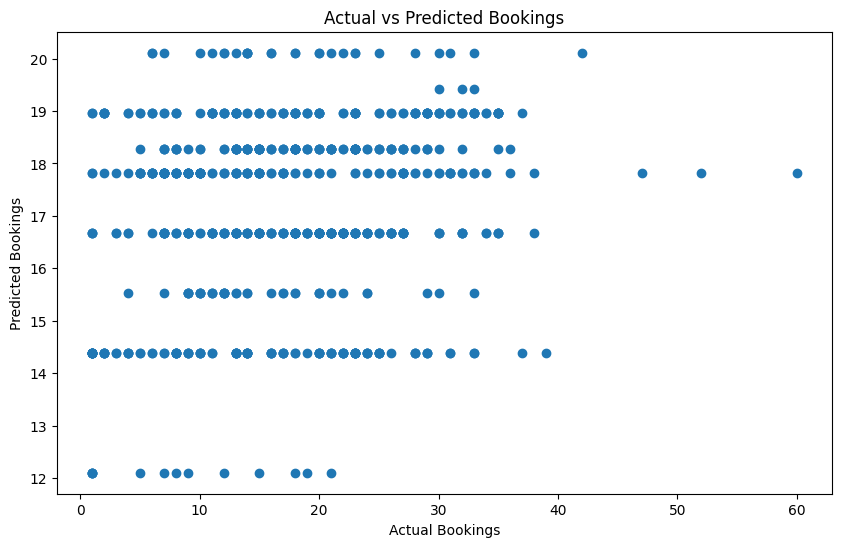

In [12]:
# =========================================================
# ACTUAL VS PREDICTED VALUES
# =========================================================

plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Bookings")
plt.ylabel("Predicted Bookings")

plt.title("Actual vs Predicted Bookings")

plt.show()

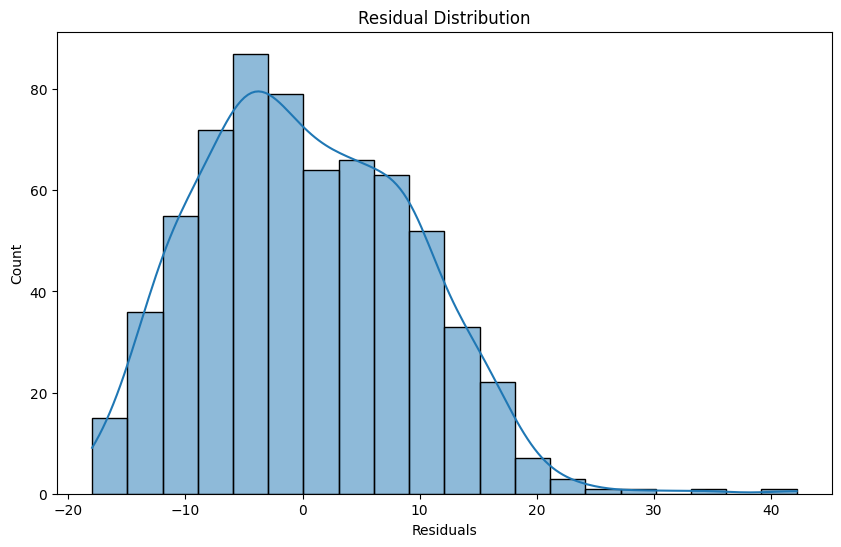

In [13]:
# =========================================================
# RESIDUAL ANALYSIS
# =========================================================

residuals = y_test - y_pred

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.show()

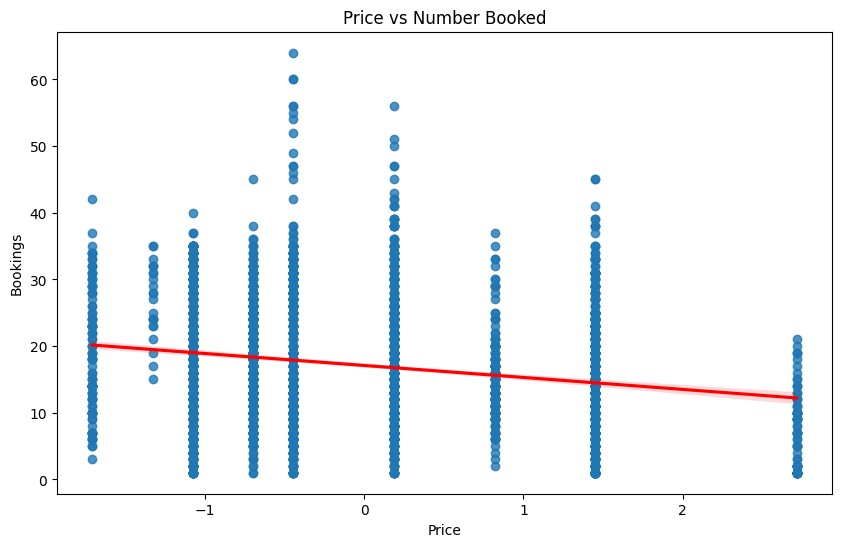

In [14]:
# =========================================================
# REGRESSION LINE VISUALIZATION
# =========================================================

plt.figure(figsize=(10,6))

sns.regplot(
    x=df['price_inr'],
    y=df['number_booked'],
    line_kws={'color': 'red'}
)

plt.title("Price vs Number Booked")

plt.xlabel("Price")
plt.ylabel("Bookings")

plt.show()

# Price Elasticity Interpretation

The regression coefficient indicates the relationship between class price and booking demand.

- A negative coefficient suggests that higher prices reduce bookings.
- A positive coefficient suggests that demand increases with price.
- The model helps estimate customer sensitivity to pricing changes.

This analysis supports dynamic pricing strategy development.

# Business Insights

- Pricing impacts customer attendance behavior.
- High-demand classes may tolerate moderate price increases.
- Low-demand periods may require promotional pricing.
- Elasticity modeling supports revenue optimization strategies.

# Conclusion

A linear regression model was successfully developed to analyze price elasticity.

The model evaluated the relationship between:
- class pricing
- booking demand

The insights generated from this model will support:
- demand forecasting
- dynamic pricing
- revenue optimization
- business decision-making